In [1]:
import pickle 
import logging
from medmnist import BreastMNIST
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import cv2
import random
from tmu.models.classification.vanilla_classifier import TMClassifier
from sklearn.metrics import roc_auc_score,  average_precision_score
from sklearn.metrics import classification_report
import json 
from time import time
import os
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.metrics import roc_curve
import optuna
from optuna.samplers import TPESampler
from sklearn.metrics import fbeta_score
import pickle
import os

/home/coder/masters_thesis/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
with open("mnist_specialist.pkl", "rb") as f:
    tm = pickle.load(f)

In [3]:
print("T (voting threshold):", tm.T)
print("s (specificity):", tm.s)
print("Weighted clauses:", tm.weighted_clauses)
print("Number of clauses per class:", tm.clause_banks[0].number_of_clauses)
print("Patch dimension:", tm.clause_banks[0].patch_dim)
print("Number of patches:", tm.clause_banks[0].number_of_patches)

print("Feature negation enabled:", tm.feature_negation)
print("Max included literals:", tm.max_included_literals)

print("Number of classes:", len(tm.weight_banks))


T (voting threshold): 1500
s (specificity): 10.0
Weighted clauses: True
Number of clauses per class: 2000
Patch dimension: (3, 3)
Number of patches: 676
Feature negation enabled: True
Max included literals: 32
Number of classes: 10


In [4]:
print("Number of clauses per class", tm.number_of_clauses)
print("Patch size:", tm.clause_banks[0].patch_dim)
print("Patches per row:", 28 - tm.clause_banks[0].patch_dim[0] + 1)
print("Total patches:", tm.clause_banks[0].number_of_patches)


Number of clauses per class 2000
Patch size: (3, 3)
Patches per row: 26
Total patches: 676


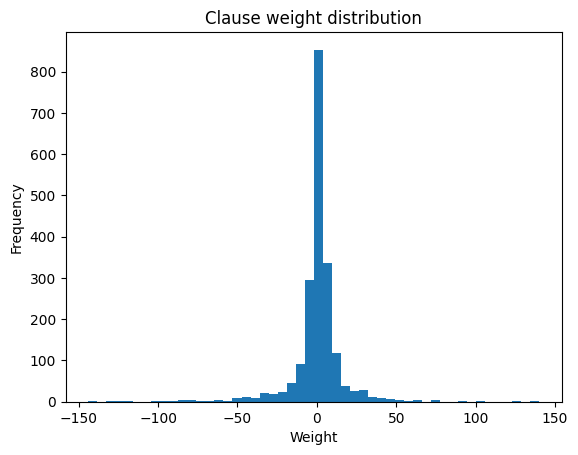

2000


In [6]:
weights = tm.weight_banks[0].get_weights()

plt.hist(weights, bins=50)
plt.title("Clause weight distribution")
plt.xlabel("Weight")
plt.ylabel("Frequency")
plt.show()
print(len(weights))

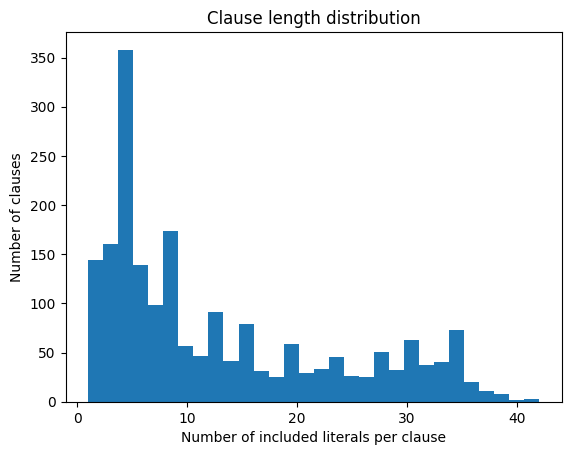

Total number of clauses: 2000


In [6]:
clause_lengths = [
    tm.number_of_include_actions(1, c)
    for c in range(tm.number_of_clauses)
]

plt.hist(clause_lengths, bins=30)
plt.xlabel("Number of included literals per clause")
plt.ylabel("Number of clauses")
plt.title("Clause length distribution")
plt.show()
total_clauses = len(clause_lengths)
print("Total number of clauses:", total_clauses)


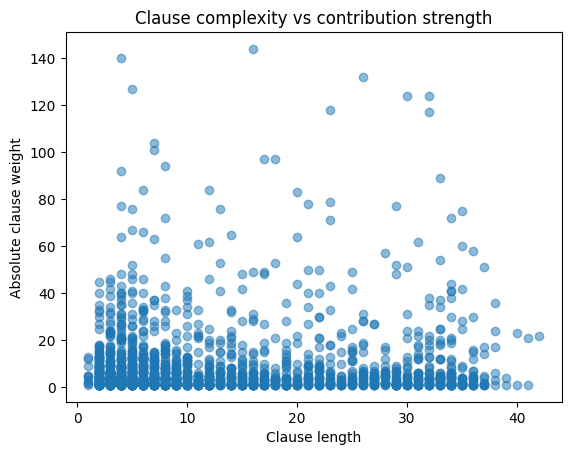

In [ ]:
weights = tm.weight_banks[0].get_weights()

plt.scatter(clause_lengths, np.abs(weights), alpha=0.5)
plt.xlabel("Clause length")
plt.ylabel("Absolute clause weight")
plt.title("Clause complexity vs contribution strength")
plt.show()


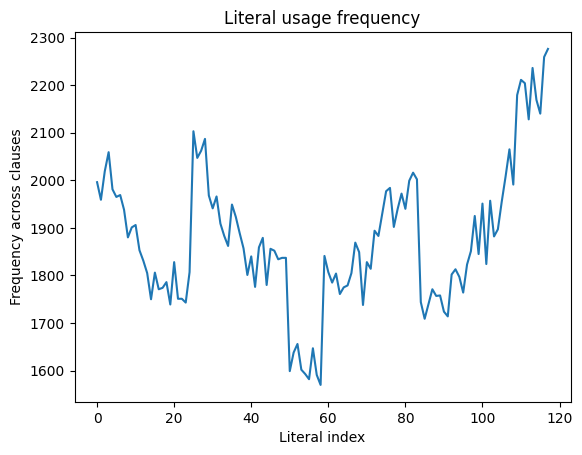

118


In [ ]:
# n how many clauses across the entire model does this literal appear?
literal_freq = tm.literal_clause_frequency()

plt.plot(literal_freq)
plt.xlabel("Literal index")
plt.ylabel("Frequency across clauses")
plt.title("Literal usage frequency")
plt.show()
print(len(literal_freq))


In [10]:
# n_classes = tm.number_of_classes

# for c in range(n_classes):
#     weights = tm.weight_banks[c].get_weights()

#     plt.figure()
#     plt.hist(weights, bins=50)
#     plt.title(f"Clause weight distribution – Class {c}")
#     plt.xlabel("Weight")
#     plt.ylabel("Frequency")
#     plt.show()


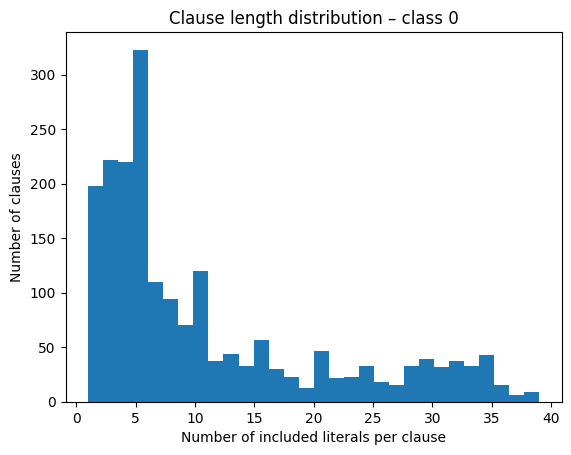

Class 0: median=7.0, mean=11.1, std=9.9


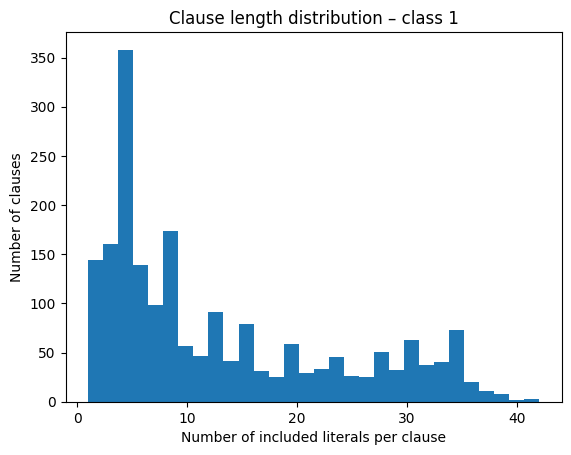

Class 1: median=9.0, mean=13.0, std=10.6


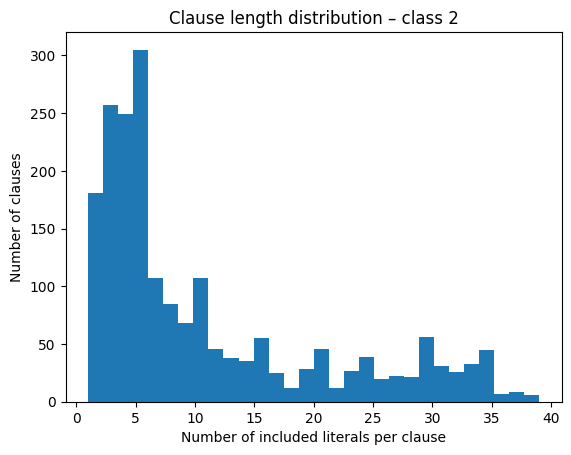

Class 2: median=7.0, mean=10.9, std=9.8


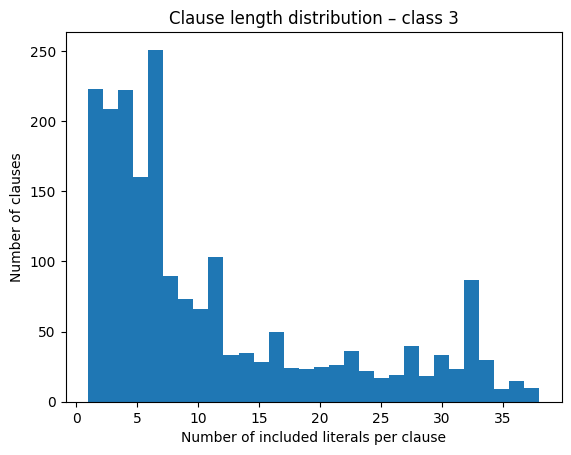

Class 3: median=7.0, mean=11.2, std=9.9


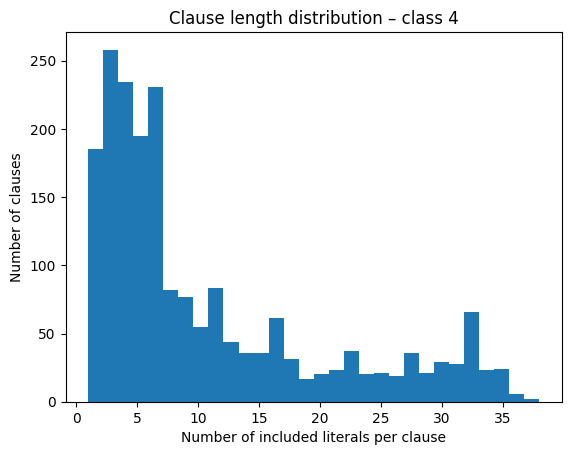

Class 4: median=7.0, mean=10.7, std=9.5


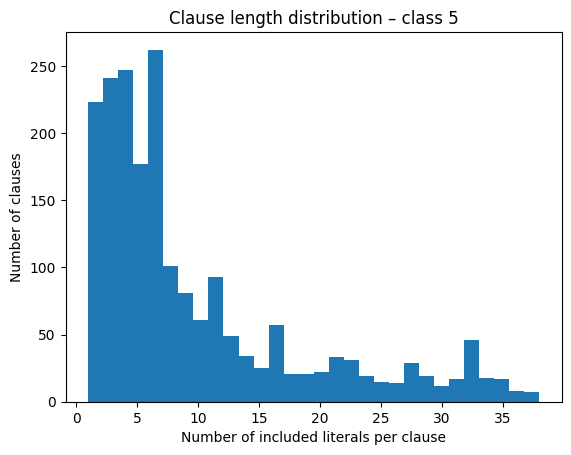

Class 5: median=6.0, mean=9.8, std=8.8


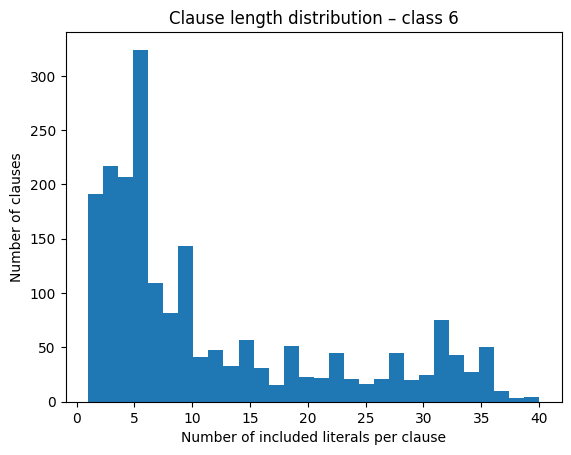

Class 6: median=7.0, mean=11.7, std=10.4


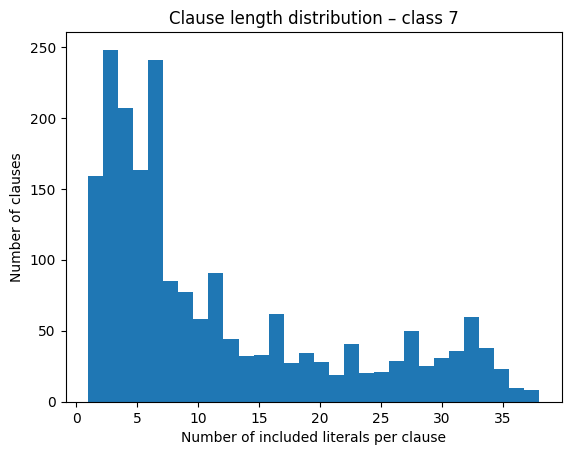

Class 7: median=7.0, mean=11.7, std=10.0


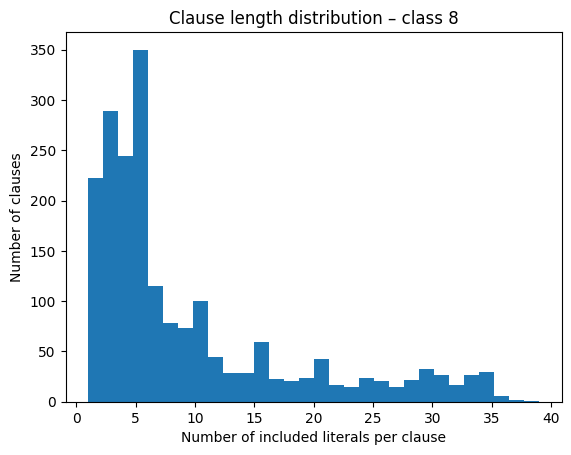

Class 8: median=6.0, mean=9.5, std=8.8


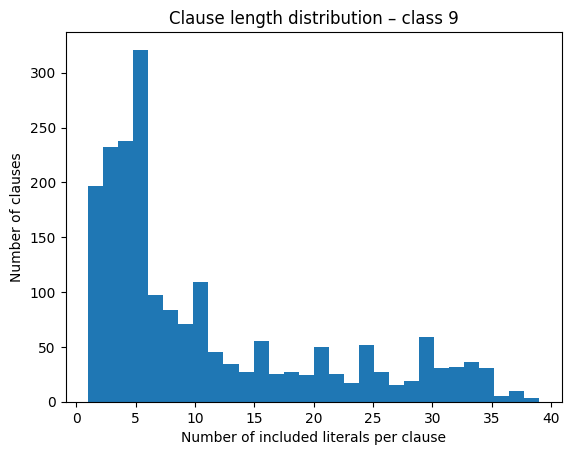

Class 9: median=7.0, mean=11.0, std=9.7


In [12]:
for cls in range(tm.number_of_classes):

    clause_lengths = [
        tm.number_of_include_actions(cls, c)
        for c in range(tm.number_of_clauses)
        if tm.number_of_include_actions(cls, c) > 0  # exclude empty clauses
    ]

    plt.hist(clause_lengths, bins=30)
    plt.xlabel("Number of included literals per clause")
    plt.ylabel("Number of clauses")
    plt.title(f"Clause length distribution – class {cls}")
    plt.show()

    print(
        f"Class {cls}: "
        f"median={np.median(clause_lengths):.1f}, "
        f"mean={np.mean(clause_lengths):.1f}, "
        f"std={np.std(clause_lengths):.1f}"
    )


/tmp/ipykernel_1472625/2292582446.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(all_clause_lengths, labels=range(tm.number_of_classes))


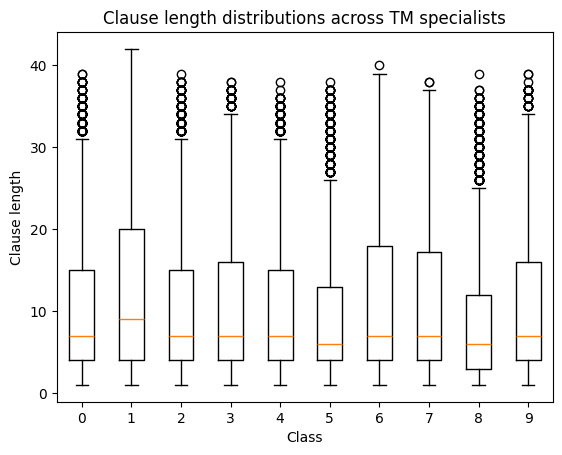

In [13]:
all_clause_lengths = []

for cls in range(tm.number_of_classes):
    lengths = [
        tm.number_of_include_actions(cls, c)
        for c in range(tm.number_of_clauses)
        if tm.number_of_include_actions(cls, c) > 0
    ]
    all_clause_lengths.append(lengths)

plt.boxplot(all_clause_lengths, labels=range(tm.number_of_classes))
plt.xlabel("Class")
plt.ylabel("Clause length")
plt.title("Clause length distributions across TM specialists")
plt.show()
